In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from skelm import ELMClassifier

In [11]:
# --- 1. The Regularized ELM Class ---
class RegularizedELM:
    def __init__(self, hidden_size=100, C=1.0, activation='tanh', random_state=None):
        """
        C: Regularization parameter (inverse of alpha). Higher C = Less regularization.
        """
        self.hidden_size = hidden_size
        self.C = C
        self.activation = activation
        self.random_state = random_state
        self.input_weights = None
        self.biases = None
        self.output_weights = None

    def _activate(self, X):
        if self.activation == 'sigmoid':
            # Numerically stable sigmoid
            return np.where(X >= 0, 1 / (1 + np.exp(-X)), np.exp(X) / (1 + np.exp(X)))
        elif self.activation == 'tanh':
            return np.tanh(X)
        elif self.activation == 'relu':
            return np.maximum(0, X)

    def fit(self, X, y):
        # Set seed for reproducibility
        if self.random_state is not None:
            np.random.seed(self.random_state)

        input_size = X.shape[1]

        # Initialize random weights (Fixed range -1 to 1 is standard for ELM)
        self.input_weights = np.random.uniform(-1, 1, (input_size, self.hidden_size))
        self.biases = np.random.uniform(-1, 1, self.hidden_size)

        # 1. Project input to hidden layer
        Z = np.dot(X, self.input_weights) + self.biases
        H = self._activate(Z)

        # 2. Calculate Output Weights using Regularized Least Squares
        # Beta = (H^T H + I/C)^-1 H^T y
        identity = np.eye(self.hidden_size)

        # We handle the matrix inversion carefully
        # (H.T @ H + identity / C) -> Regularization term added to diagonal
        H_aug = np.dot(H.T, H) + (identity / self.C)

        # Solve linear system (faster and more stable than explicit inverse)
        # We calculate H^T * y first
        HtY = np.dot(H.T, y)
        self.output_weights = np.linalg.solve(H_aug, HtY)

    def predict_proba(self, X):
        """Returns raw continuous scores (probabilities-ish)"""
        Z = np.dot(X, self.input_weights) + self.biases
        H = self._activate(Z)
        return np.dot(H, self.output_weights)

    def predict(self, X, threshold=0.5):
        scores = self.predict_proba(X)
        return (scores > threshold).astype(int)

In [12]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
targetCol = 'Gallstone Status'

In [13]:
df = pd.read_csv(filePath)

X = df.drop(columns=[targetCol])
y = df[targetCol]
scaler = StandardScaler()
X_processed = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [17]:
model = ELMClassifier(n_neurons=500, ufunc='relu')
model.fit(X_train_resampled, y_train_resampled)

preds = model.predict(X_test)

# Check if we successfully predicted the positive class
report = classification_report(y_test, preds, output_dict=True)

# Robustly get F1 score for class '1' (Works even if class is integer 1 or string '1')
f1 = report.get('1', report.get(1, {'f1-score': 0}))['f1-score']


y_pred_binary = model.predict(X_test)

print("\n=== Detailed Report ===")
print(classification_report(y_test, y_pred_binary))

# ROC AUC Score
raw_scores = model.predict_proba(X_test)
auc = roc_auc_score(y_test, raw_scores)
print(f"ROC-AUC Score: {auc:.4f}")

# Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_binary), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (ELM -)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


=== Detailed Report ===
              precision    recall  f1-score   support

           0       0.67      0.75      0.71        32
           1       0.71      0.62      0.67        32

    accuracy                           0.69        64
   macro avg       0.69      0.69      0.69        64
weighted avg       0.69      0.69      0.69        64



ValueError: y should be a 1d array, got an array of shape (64, 2) instead.

Training on 258 samples (38 features)...
Hidden Nodes: 500 | F1-Score (Positive Class): 0.7692

Best Model Found: 500 Hidden Nodes

=== Detailed Report ===
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        32
           1       0.76      0.78      0.77        32

    accuracy                           0.77        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.77      0.77      0.77        64

ROC-AUC Score: 0.7334


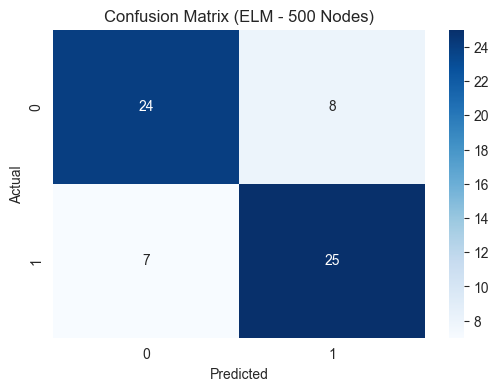

In [19]:
best_score = 0
best_model = None
best_nodes = 0

print(f"Training on {X_train_resampled.shape[0]} samples ({X_train_resampled.shape[1]} features)...")

for nodes in [500]:
    model = RegularizedELM(hidden_size=nodes, C=10.0, activation='tanh', random_state=42)
    model.fit(X_train_resampled, y_train_resampled)

    preds = model.predict(X_test)

    # Check if we successfully predicted the positive class
    report = classification_report(y_test, preds, output_dict=True)

    # Robustly get F1 score for class '1' (Works even if class is integer 1 or string '1')
    f1 = report.get('1', report.get(1, {'f1-score': 0}))['f1-score']

    if f1 > best_score:
        best_score = f1
        best_model = model
        best_nodes = nodes
    print(f"Hidden Nodes: {nodes} | F1-Score (Positive Class): {f1:.4f}")

print(f"\nBest Model Found: {best_nodes} Hidden Nodes")

# --- 4. Final Evaluation ---
y_pred_binary = best_model.predict(X_test)

print("\n=== Detailed Report ===")
print(classification_report(y_test, y_pred_binary))

# ROC AUC Score
raw_scores = best_model.predict_proba(X_test)
auc = roc_auc_score(y_test, raw_scores)
print(f"ROC-AUC Score: {auc:.4f}")

# Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_binary), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (ELM - {best_nodes} Nodes)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()